# Dynamic Quantization – Post-Training
## Lung Cancer Classification (CNN + Attention + SVM)

### Perbedaan dengan Static Quantization:

| Aspek | Static PTQ | **Dynamic PTQ** |
|-------|-----------|-----------------|
| Representative dataset | ✅ Required | ❌ Not needed |
| Scale activations | Offline (fixed) | **Online (per-batch)** |
| Weights quantization | Offline | Offline |
| Setup complexity | Medium | **Simple** |
| Inference speed | Faster | Slightly slower |
| Accuracy | Slightly better | Good |

### Metode yang diuji:
- **FP16** – Weights dikurangi ke 16-bit float (dynamic, tanpa calibration)
- **INT8 Dynamic** – Weights INT8, activations diquantize saat runtime

## 1. Imports & Setup

In [1]:
import os, time, json, shutil
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_auc_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU'))} device(s)")


TensorFlow : 2.21.0
GPU        : 0 device(s)


## 2. Custom Layer

In [2]:
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        from tensorflow.keras.layers import (GlobalAveragePooling2D,
                                             Dense, Reshape, Multiply)
        ch = input_shape[-1]
        self.gap     = GlobalAveragePooling2D()
        self.dense1  = Dense(max(1, ch // self.ratio), activation="relu")
        self.dense2  = Dense(ch, activation="sigmoid")
        self.reshape = Reshape((1, 1, ch))
        super().build(input_shape)

    def call(self, x):
        from tensorflow.keras.layers import Multiply
        a = self.gap(x)
        a = self.dense1(a)
        a = self.dense2(a)
        a = self.reshape(a)
        return Multiply()([x, a])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"ratio": self.ratio})
        return cfg

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}
print("✅ ChannelAttention defined")


✅ ChannelAttention defined


## 3. Helper Functions

In [3]:
def get_size_kb(path):
    return os.path.getsize(path) / 1024 if os.path.exists(path) else 0.0


class TFLiteExtractor:
    """Wrapper untuk TFLite interpreter agar mirip interface Keras .predict()"""
    def __init__(self, model_path):
        self.interpreter = tf.lite.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()
        self.inp = self.interpreter.get_input_details()
        self.out = self.interpreter.get_output_details()

    def predict(self, X, verbose=0, batch_size=None):
        feats = []
        for img in X:
            self.interpreter.set_tensor(self.inp[0]['index'],
                                        img[np.newaxis].astype(np.float32))
            self.interpreter.invoke()
            feats.append(self.interpreter.get_tensor(self.out[0]['index'])[0])
        return np.array(feats)



PREDICT_BATCH_SIZE = 16

def predict_features(extractor, X):
    try:
        return extractor.predict(X, verbose=0, batch_size=PREDICT_BATCH_SIZE)
    except TypeError:
        return extractor.predict(X, verbose=0)
def evaluate_model(extractor, svm, scaler, X, y_true, class_names, label, warmup=True):
    """Evaluasi lengkap dan kembalikan dict metrik"""
    # Feature extraction
    if warmup:
        warmup_n = min(2, len(X))
        if warmup_n > 0:
            _ = predict_features(extractor, X[:warmup_n])
    t0 = time.perf_counter()
    feats = predict_features(extractor, X)
    feat_time = time.perf_counter() - t0

    # SVM inference
    t0 = time.perf_counter()
    X_sc   = scaler.transform(feats)
    y_pred = svm.predict(X_sc)
    y_prob = svm.predict_proba(X_sc)
    inf_time = time.perf_counter() - t0

    acc  = accuracy_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    rep  = classification_report(y_true, y_pred,
                                  target_names=class_names, output_dict=True)
    sens = rep['macro avg']['recall']
    prec = rep['macro avg']['precision']
    f1   = rep['macro avg']['f1-score']

    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    spec = np.mean(specs)

    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    auc   = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

    return dict(label=label, accuracy=acc, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, auc=auc, cm=cm,
                feat_time=feat_time, inf_time=inf_time)


print("✅ Helper functions defined")


✅ Helper functions defined


## 4. Load Dataset

In [4]:
print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

# ── Auto-detect dataset path ──────────────────────────────────────────────────
SCRIPT_DIR = os.getcwd()
for candidate in [
    os.path.join(os.path.dirname(SCRIPT_DIR), "dataset_processed2"),
    "../dataset_processed2",
    "dataset_processed2",
]:
    if os.path.exists(candidate):
        dataset_base_path = candidate
        break

IMG_SIZE   = 224
categories = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names = ["Bengin", "Malignant", "Normal"]

def load_split(split):
    X, y = [], []
    for idx, cat in enumerate(categories):
        cat_path = os.path.join(dataset_base_path, split, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img.astype(np.float32) / 255.0)
            y.append(idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading …")
X_train, y_train = load_split("train")
X_valid, y_valid = load_split("valid")
X_test,  y_test  = load_split("test")

print(f"Train : {X_train.shape}")
print(f"Valid : {X_valid.shape}")
print(f"Test  : {X_test.shape}")
print("\nClass distribution (train):")
for i, nm in enumerate(class_names):
    n = np.sum(y_train == i)
    print(f"  {nm:<12}: {n:4d} ({n/len(y_train)*100:5.2f}%)")


LOADING DATASET
Loading …
Train : (737, 224, 224, 3)
Valid : (158, 224, 224, 3)
Test  : (159, 224, 224, 3)

Class distribution (train):
  Bengin      :   71 ( 9.63%)
  Malignant   :  383 (51.97%)
  Normal      :  283 (38.40%)


## 5. Load Baseline Model


In [5]:
print("=" * 70)
print("LOADING BASELINE MODEL")
print("=" * 70)

# ⚠️ UPDATE THIS PATH ──────────────────────────────────────────────────────────
ORIG_FOLDER = "saved_models_original"

if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(
        f"Folder '{ORIG_FOLDER}' tidak ditemukan. "
        "Jalankan training terlebih dahulu atau update ORIG_FOLDER."
    )

print(f"Loading from: {ORIG_FOLDER}/")
model_baseline    = tf.keras.models.load_model(
    os.path.join(ORIG_FOLDER, "cnn_attention_model.keras"),
    custom_objects=CUSTOM_OBJECTS)
extractor_baseline = tf.keras.models.load_model(
    os.path.join(ORIG_FOLDER, "feature_extractor.keras"),
    custom_objects=CUSTOM_OBJECTS)
svm_baseline    = joblib.load(os.path.join(ORIG_FOLDER, "svm_classifier.pkl"))
scaler_baseline = joblib.load(os.path.join(ORIG_FOLDER, "feature_scaler.pkl"))

print(f"✅ Loaded  |  Params: {model_baseline.count_params():,}")

print("\nEvaluating baseline …")
metrics_baseline = evaluate_model(extractor_baseline, svm_baseline, scaler_baseline,
                                   X_test, y_test, class_names, "Baseline (FP32)")
print(f"✅ Baseline Accuracy: {metrics_baseline['accuracy']:.4f}")


LOADING BASELINE MODEL
Loading from: saved_models_original/

✅ Loaded  |  Params: 1,627,343

Evaluating baseline …
✅ Baseline Accuracy: 0.9937


## 6. Dynamic Quantization – Konsep

### Cara Kerja:
```
FP32 Weights  →  [offline] quantize → INT8 / FP16 Weights (disimpan di file)
FP32 Input    →  [online, saat inference] compute activation → diquantize secara dinamis
```

### Perbedaan kunci vs Static:
```python
# STATIC (quantization.ipynb)
converter.representative_dataset = rep_dataset   # ← butuh dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# scale & zero_point activations sudah FIXED saat konversi

# DYNAMIC (notebook ini)  ← TIDAK ada representative_dataset
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# scale & zero_point activations dihitung SAAT RUNTIME per-batch
```

### Dua varian yang diuji:
| # | Variant | Weights | Activations |
|---|---------|---------|------------|
| 1 | **FP16 Dynamic** | FP16 (offline) | FP32 (no quant) |
| 2 | **INT8 Dynamic** | INT8 (offline) | FP32 → diquantize online |


## 7. FP16 Dynamic Quantization

Weights dikonversi ke **FP16** secara offline.  
Activations tetap **FP32** – tidak ada calibration diperlukan.

In [6]:
print("=" * 70)
print("FP16 DYNAMIC QUANTIZATION")
print("=" * 70)

# ── Konversi ──────────────────────────────────────────────────────────────────
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(extractor_baseline)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
# TIDAK ada representative_dataset  ← kunci dynamic!

tflite_fp16 = converter_fp16.convert()

os.makedirs("artifacts", exist_ok=True)
fp16_path = "artifacts/dynamic_fp16.tflite"
with open(fp16_path, "wb") as f:
    f.write(tflite_fp16)

size_fp16 = len(tflite_fp16) / 1024
print(f"✅ FP16 saved  |  Size: {size_fp16:.2f} KB")

# ── Verifikasi tipe tensor ────────────────────────────────────────────────────
interp_check = tf.lite.Interpreter(model_path=fp16_path)
interp_check.allocate_tensors()
inp_detail = interp_check.get_input_details()[0]
out_detail = interp_check.get_output_details()[0]
print(f"   Input  dtype : {inp_detail['dtype']}")
print(f"   Output dtype : {out_detail['dtype']}")

# ── Ekstrak fitur & Train SVM ─────────────────────────────────────────────────
print("\nExtracting features …")
ex_fp16    = TFLiteExtractor(fp16_path)
X_tr_fp16  = ex_fp16.predict(X_train)
X_val_fp16 = ex_fp16.predict(X_valid)

scaler_fp16 = StandardScaler()
X_sc        = scaler_fp16.fit_transform(np.vstack([X_tr_fp16, X_val_fp16]))
y_comb      = np.concatenate([y_train, y_valid])

print("Training SVM (C=0.1, gamma='scale', class_weight='balanced') …")
svm_fp16 = SVC(kernel='rbf', C=0.1, gamma='scale',
               probability=True, random_state=SEED, class_weight="balanced")
svm_fp16.fit(X_sc, y_comb)

metrics_fp16 = evaluate_model(ex_fp16, svm_fp16, scaler_fp16,
                               X_test, y_test, class_names, "FP16 Dynamic")
print(f"✅ FP16 Dynamic Accuracy: {metrics_fp16['accuracy']:.4f}")


FP16 DYNAMIC QUANTIZATION
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5l42ix7q\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5l42ix7q\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp5l42ix7q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  1415868826896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868294144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868833936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869050624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869052736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869040064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868982624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868982096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869047632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869052208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415

d:\bintang\skripsi 0606\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training SVM (C=0.1, gamma='scale', class_weight='balanced') …
✅ FP16 Dynamic Accuracy: 0.9937


## 8. INT8 Dynamic Quantization

Weights dikonversi ke **INT8** secara offline.  
Activations **tidak** di-quantize secara offline – scale dihitung **saat runtime** per-input.  
> Berbeda dengan Static INT8 yang menggunakan `representative_dataset`.

In [7]:
print("=" * 70)
print("INT8 DYNAMIC QUANTIZATION")
print("=" * 70)

# ── Konversi ──────────────────────────────────────────────────────────────────
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(extractor_baseline)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
# ← TIDAK set representative_dataset  (inilah yang membuat dynamic)
# ← TIDAK set target_spec.supported_ops ke TFLITE_BUILTINS_INT8
#    sehingga TFLite hanya quantize weights ke INT8,
#    activations dihitung dinamis saat runtime

tflite_int8 = converter_int8.convert()

int8_path = "artifacts/dynamic_int8.tflite"
with open(int8_path, "wb") as f:
    f.write(tflite_int8)

size_int8 = len(tflite_int8) / 1024
print(f"✅ INT8 Dynamic saved  |  Size: {size_int8:.2f} KB")

# ── Verifikasi tipe tensor ────────────────────────────────────────────────────
interp_check2 = tf.lite.Interpreter(model_path=int8_path)
interp_check2.allocate_tensors()
inp_detail2 = interp_check2.get_input_details()[0]
out_detail2 = interp_check2.get_output_details()[0]
print(f"   Input  dtype : {inp_detail2['dtype']}")   # float32 (dynamic!)
print(f"   Output dtype : {out_detail2['dtype']}")   # float32 (dynamic!)

# ── Ekstrak fitur & Train SVM ─────────────────────────────────────────────────
print("\nExtracting features …")
ex_int8    = TFLiteExtractor(int8_path)
X_tr_int8  = ex_int8.predict(X_train)
X_val_int8 = ex_int8.predict(X_valid)

scaler_int8 = StandardScaler()
X_sc_int8   = scaler_int8.fit_transform(np.vstack([X_tr_int8, X_val_int8]))
y_comb_int8 = np.concatenate([y_train, y_valid])

print("Training SVM (C=0.1, gamma='scale', class_weight='balanced') …")
svm_int8 = SVC(kernel='rbf', C=0.1, gamma='scale',
               probability=True, random_state=SEED, class_weight="balanced")
svm_int8.fit(X_sc_int8, y_comb_int8)

metrics_int8 = evaluate_model(ex_int8, svm_int8, scaler_int8,
                               X_test, y_test, class_names, "INT8 Dynamic")
print(f"✅ INT8 Dynamic Accuracy: {metrics_int8['accuracy']:.4f}")


INT8 DYNAMIC QUANTIZATION
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_qnosnhv\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_qnosnhv\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp_qnosnhv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  1415868826896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868294144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868833936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869050624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869052736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869040064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868982624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415868982096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869047632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415869052208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1415

d:\bintang\skripsi 0606\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training SVM (C=0.1, gamma='scale', class_weight='balanced') …
✅ INT8 Dynamic Accuracy: 0.9937


## 9. Save Artifacts

In [8]:
print("=" * 70)
print("SAVING ARTIFACTS")
print("=" * 70)

timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
save_folder = f"saved_models_dynamic_quant_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

# TFLite models
shutil.copy2(fp16_path, os.path.join(save_folder, "extractor_fp16_dynamic.tflite"))
shutil.copy2(int8_path, os.path.join(save_folder, "extractor_int8_dynamic.tflite"))

# SVM & scalers
joblib.dump(svm_fp16,    os.path.join(save_folder, "svm_fp16.pkl"))
joblib.dump(scaler_fp16, os.path.join(save_folder, "scaler_fp16.pkl"))
joblib.dump(svm_int8,    os.path.join(save_folder, "svm_int8.pkl"))
joblib.dump(scaler_int8, os.path.join(save_folder, "scaler_int8.pkl"))

# Baseline reference
model_baseline.save(os.path.join(save_folder, "baseline.keras"))
joblib.dump(svm_baseline,    os.path.join(save_folder, "svm_baseline.pkl"))
joblib.dump(scaler_baseline, os.path.join(save_folder, "scaler_baseline.pkl"))

print(f"✅ Saved to: {save_folder}/")


SAVING ARTIFACTS
✅ Saved to: saved_models_dynamic_quant_20260608_203225/


## 10. Comprehensive Comparison Table

Semua metrik: **Accuracy, Sensitivity, Specificity, Precision, F1, AUC,  
Feat Ext (ms), SVM Inf (ms), Total (ms)**

In [9]:
print()
print("="*70)
print("COMPARISON TABLE")
print("="*70)
print("Note: Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)")

results = [metrics_baseline, metrics_fp16, metrics_int8]
all_results = results

# Size mengikuti aturan notebook lain: ukuran pipeline inferensi lengkap.
# Baseline memakai feature extractor asli, bukan full CNN training model.
size_baseline = (
    get_size_kb(os.path.join(ORIG_FOLDER, "feature_extractor.keras"))
    + get_size_kb(os.path.join(ORIG_FOLDER, "svm_classifier.pkl"))
    + get_size_kb(os.path.join(ORIG_FOLDER, "feature_scaler.pkl"))
)
size_fp16_pipeline = (
    get_size_kb(os.path.join(save_folder, "extractor_fp16_dynamic.tflite"))
    + get_size_kb(os.path.join(save_folder, "svm_fp16.pkl"))
    + get_size_kb(os.path.join(save_folder, "scaler_fp16.pkl"))
)
size_int8_pipeline = (
    get_size_kb(os.path.join(save_folder, "extractor_int8_dynamic.tflite"))
    + get_size_kb(os.path.join(save_folder, "svm_int8.pkl"))
    + get_size_kb(os.path.join(save_folder, "scaler_int8.pkl"))
)

sizes = [size_baseline, size_fp16_pipeline, size_int8_pipeline]

# Build table
comp_data = []
for i, m in enumerate(results):
    comp_data.append({
        "Model": m['label'],
        "Size (KB)": f"{sizes[i]:.2f}",
        "Compression": f"{sizes[0]/sizes[i]:.2f}x",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "Precision": f"{m['precision']:.4f}",
        "F1-Score": f"{m['f1']:.4f}",
        "AUC": f"{m['auc']:.4f}",
        "Feat Ext (ms)": f"{m['feat_time']*1000:.2f}",
        "SVM Inf (ms)": f"{m['inf_time']*1000:.2f}",
        "Total (ms)": f"{(m['feat_time']+m['inf_time'])*1000:.2f}"
    })

df_comp = pd.DataFrame(comp_data)
print()
print(df_comp.to_string(index=False))

# Save CSV/JSON
comparison_csv_path = os.path.join(save_folder, "comparison.csv")
comparison_json_path = os.path.join(save_folder, "comparison_table.json")
df_comp.to_csv(comparison_csv_path, index=False)
df_comp.to_json(comparison_json_path, orient="records", indent=2)

summary = {}
for i, m in enumerate(results):
    key = m['label'].lower().replace(' ', '_').replace('(', '').replace(')', '')
    summary[key] = {
        'accuracy': float(m['accuracy']),
        'sensitivity': float(m['sensitivity']),
        'specificity': float(m['specificity']),
        'precision': float(m['precision']),
        'f1': float(m['f1']),
        'auc': float(m['auc']),
        'size_kb': float(sizes[i]),
        'feat_time_ms': float(m['feat_time'] * 1000),
        'inf_time_ms': float(m['inf_time'] * 1000),
        'total_time_ms': float((m['feat_time'] + m['inf_time']) * 1000),
        'degradation_pct': float((results[0]['accuracy'] - m['accuracy']) / results[0]['accuracy'] * 100) if i > 0 else 0.0,
        'speedup': float((results[0]['feat_time'] + results[0]['inf_time']) / (m['feat_time'] + m['inf_time']))
    }

summary_path = os.path.join(save_folder, "summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print()
print("comparison.csv, comparison_table.json & summary.json saved")



COMPARISON TABLE
Note: Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)

          Model Size (KB) Compression Accuracy Sensitivity Specificity Precision F1-Score    AUC Feat Ext (ms) SVM Inf (ms) Total (ms)
Baseline (FP32)   6454.70       1.00x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1094.06         5.20    1099.26
   FP16 Dynamic   3237.15       1.99x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1520.15         4.80    1524.95
   INT8 Dynamic   1651.33       3.91x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1088.70         4.51    1093.21

comparison.csv, comparison_table.json & summary.json saved


## 11. Visualizations

CREATING VISUALIZATIONS
✅ comparison_plots.png saved


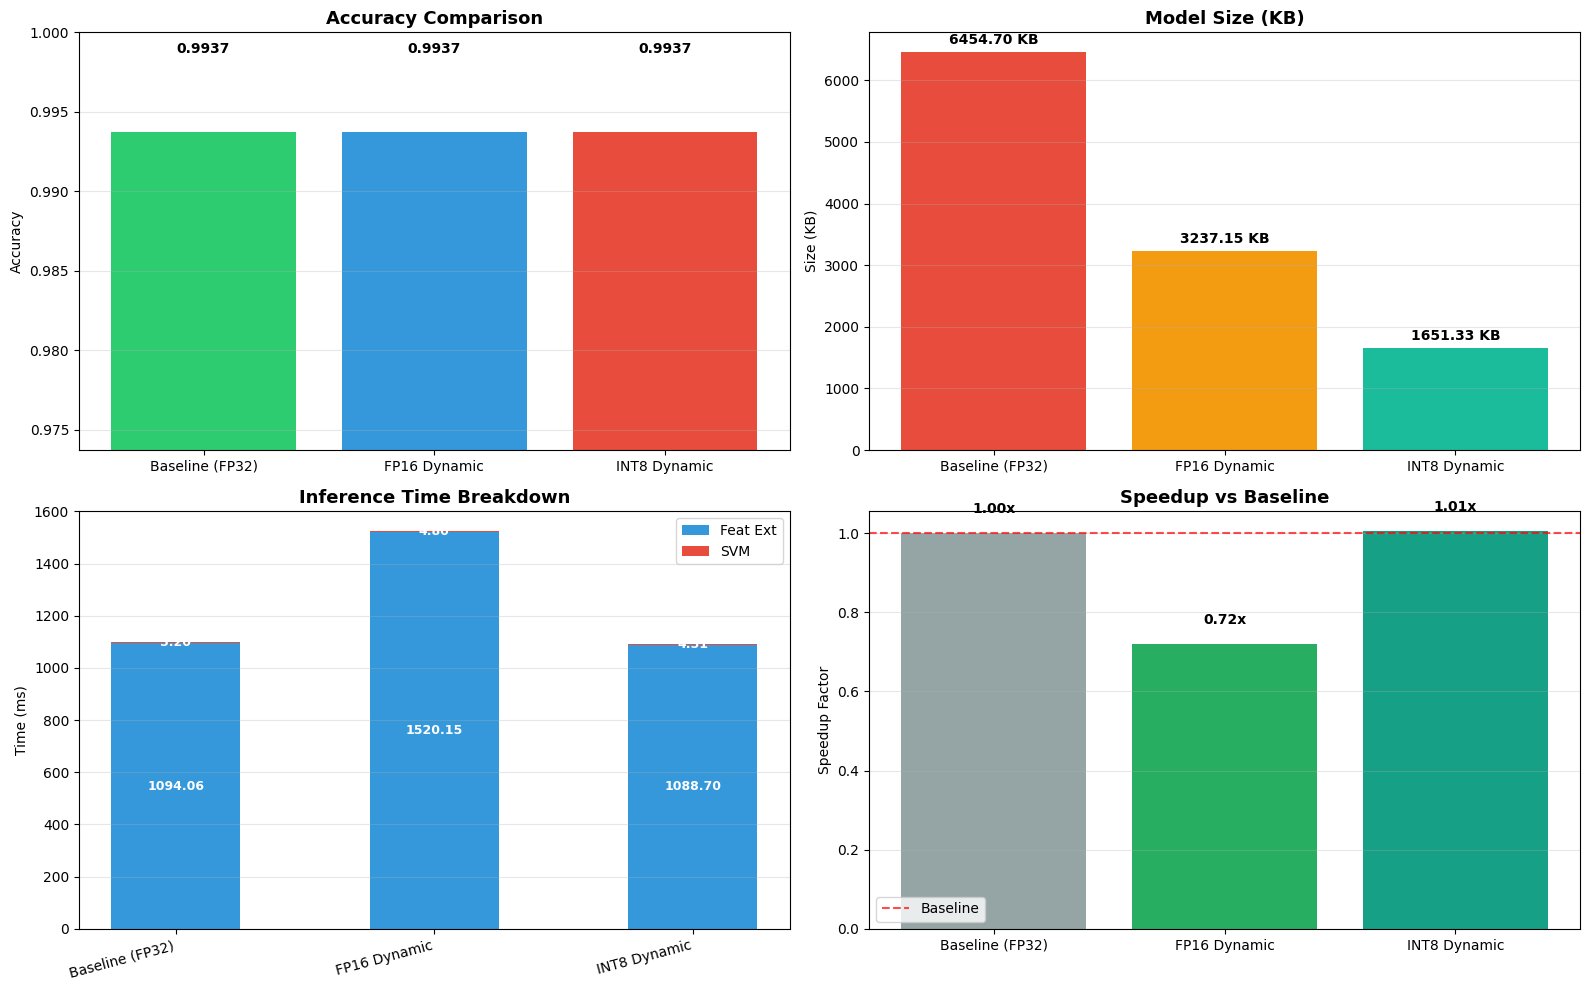

✅ confusion_matrices.png saved


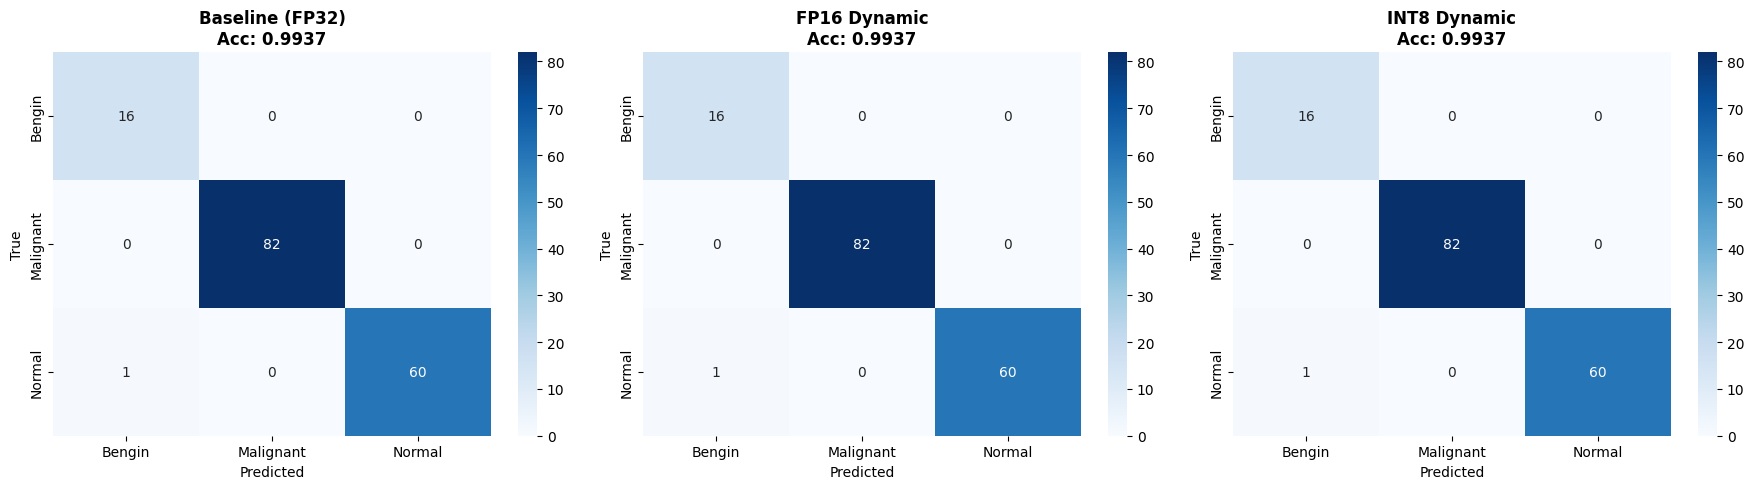

In [10]:
print("=" * 70)
print("CREATING VISUALIZATIONS")
print("=" * 70)

labels    = [m['label'] for m in all_results]
colors3   = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Accuracy ─────────────────────────────────────────────────────────────────
acc_vals = [m['accuracy'] for m in all_results]
bars = axes[0,0].bar(labels, acc_vals, color=colors3)
axes[0,0].set_ylim(min(acc_vals) - 0.02, 1.0)
axes[0,0].set_title("Accuracy Comparison", fontsize=13, fontweight='bold')
axes[0,0].set_ylabel("Accuracy")
axes[0,0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, acc_vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.005, f'{v:.4f}',
                   ha='center', fontweight='bold')

# 2. Model Size ───────────────────────────────────────────────────────────────
bars = axes[0,1].bar(labels, sizes, color=['#e74c3c','#f39c12','#1abc9c'])
axes[0,1].set_title("Model Size (KB)", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Size (KB)")
axes[0,1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, sizes):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+max(sizes)*0.02,
                   f'{v:.2f} KB', ha='center', fontweight='bold')

# 3. Inference Time (Stacked) ─────────────────────────────────────────────────
feat_t = [m['feat_time']*1000 for m in all_results]
svm_t  = [m['inf_time']*1000  for m in all_results]
x      = np.arange(len(labels))
b1 = axes[1,0].bar(x, feat_t, 0.5, label='Feat Ext', color='#3498db')
b2 = axes[1,0].bar(x, svm_t,  0.5, bottom=feat_t, label='SVM', color='#e74c3c')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, rotation=15, ha='right')
axes[1,0].set_ylabel('Time (ms)')
axes[1,0].set_title('Inference Time Breakdown', fontsize=13, fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(axis='y', alpha=0.3)
for i,(f,s) in enumerate(zip(feat_t, svm_t)):
    axes[1,0].text(i, f/2,   f'{f:.2f}', ha='center', va='center',
                   color='white', fontweight='bold', fontsize=9)
    axes[1,0].text(i, f+s/2, f'{s:.2f}', ha='center', va='center',
                   color='white', fontweight='bold', fontsize=9)

# 4. Speedup ──────────────────────────────────────────────────────────────────
total_t  = [f+s for f,s in zip(feat_t, svm_t)]
speedups = [total_t[0]/t for t in total_t]
bars = axes[1,1].bar(labels, speedups, color=['#95a5a6','#27ae60','#16a085'])
axes[1,1].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Baseline')
axes[1,1].set_title('Speedup vs Baseline', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Speedup Factor')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, speedups):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.05, f'{v:.2f}x',
                   ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "comparison_plots.png"),
            dpi=150, bbox_inches='tight')
print("✅ comparison_plots.png saved")
plt.show()
plt.close()

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, all_results):
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f"{m['label']}\nAcc: {m['accuracy']:.4f}", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "confusion_matrices.png"),
            dpi=150, bbox_inches='tight')
print("✅ confusion_matrices.png saved")
plt.show()
plt.close()


## 12. Final Summary

In [11]:
print()
print("=" * 70)
print("DYNAMIC QUANTIZATION COMPLETE!")
print("=" * 70)
print()
print(f"Saved to: {save_folder}/")
print()
print("Summary:")
print("Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)")
for i, (m, sz) in enumerate(zip(all_results, sizes)):
    deg = (all_results[0]['accuracy'] - m['accuracy']) / all_results[0]['accuracy'] * 100
    speedup = (all_results[0]['feat_time'] + all_results[0]['inf_time']) / (m['feat_time'] + m['inf_time'])
    print()
    print(f"{m['label']}:")
    print(f"  Accuracy    : {m['accuracy']:.4f}  ({deg:+.2f}% degradation)")
    print(f"  Size        : {sz:.2f} KB  ({size_baseline/sz:.2f}x compression)")
    print(f"  Total time  : {(m['feat_time']+m['inf_time'])*1000:.2f} ms  ({speedup:.2f}x speedup)")

print()
print("Files:")
for fn in sorted(os.listdir(save_folder)):
    print(f"   - {save_folder}/{fn}")
print("=" * 70)



DYNAMIC QUANTIZATION COMPLETE!

Saved to: saved_models_dynamic_quant_20260608_203225/

Summary:
Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)

Baseline (FP32):
  Accuracy    : 0.9937  (+0.00% degradation)
  Size        : 6454.70 KB  (1.00x compression)
  Total time  : 1099.26 ms  (1.00x speedup)

FP16 Dynamic:
  Accuracy    : 0.9937  (+0.00% degradation)
  Size        : 3237.15 KB  (1.99x compression)
  Total time  : 1524.95 ms  (0.72x speedup)

INT8 Dynamic:
  Accuracy    : 0.9937  (+0.00% degradation)
  Size        : 1651.33 KB  (3.91x compression)
  Total time  : 1093.21 ms  (1.01x speedup)

Files:
   - saved_models_dynamic_quant_20260608_203225/baseline.keras
   - saved_models_dynamic_quant_20260608_203225/comparison.csv
   - saved_models_dynamic_quant_20260608_203225/comparison_plots.png
   - saved_models_dynamic_quant_20260608_203225/comparison_table.json
   - saved_models_dynamic_quant_20260608_203225/confusion_matrices.png
   - saved_models_dynamic_quant_2